In [ ]:
from pathlib import Path
import numpy as np
import math, random, os, sys, importlib, time
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, plot_x_safety_map
from data.datasets import SpringDataset, make_sequence_pairs


In [3]:
from train.models import (
    MLPEncoder, MLPDecoder, RNNBackbone,
    CondRNNModel, ConditionalSequenceModel, EncoderOnly, build_cond_gru_model
)
from train.training import train_epoch, train_epoch_mmd_only, eval_epoch, eval_epoch_enc
from train.losses import mmd2_unif
from hypo_test.stats_tests import chisq_uniform_1d


In [3]:


z_0 = np.array([0.0, 0.0])  # baseline configuration
params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters
mean = np.array([0,0]); cov = np.diag([1, 1]) # parameters of the X distribution

tau = 1 # safety upper threshold for trajectory
time_window = (6, 10) # inspection window
T = 10; dt = 0.05 # t \in [0,T] with step dt = 0.01
seed = 1 # random seed


X = sample_x(n_samples = 5000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T array), position (n * T array), velocity (n * T array)
traj = simulate_spring(params, t_final=T, dt=dt, X=X, forcing_type='sin', config=z_0)

In [4]:
# 1. we need an encoder encoder X to latent V
# 2. random latent state h_t, that is updated in a RNN/Neural ODE style h_{t+1} = phi(o_t,h_t,v_i)
# 3. reconstruct o_{t+1} with h_{t+1}, say psi(t+1)
# 4. say we want unifrom V_i mean over tau? and 

In [ ]:

# ---- use your existing X, traj ----
# X: (N, 2)
# traj['s']: (N, T_full)
s = traj["s"]  # numpy array
assert X.shape[0] == s.shape[0]

# optionally to downsample the trajectory to reduce length (meaning effective dt is stride * df)
stride = 1                  # dt=0.01 => stride=10 gives effective dt=0.1
s_ds = s[:, ::stride]        # (N, T_ds)
T_ds = s_ds.shape[1]

# build (o_hist, o_next) pairs for next-step prediction
# o_hist: s[0:T-1], o_next: s[1:T]
o_hist = s_ds[:, :-1].astype(np.float32)[:, :, None]   # (N, T-1, 1)
o_next = s_ds[:,  1:].astype(np.float32)[:, :, None]   # (N, T-1, 1)
x_np   = X.astype(np.float32)                           # (N, 2)


In [ ]:
# train/val split
N = x_np.shape[0]
perm = np.random.RandomState(0).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]
X_train = x_np[tr_idx]
X_val = x_np[va_idx]
train_ds = SpringDataset(X_train, o_hist[tr_idx], o_next[tr_idx])
val_ds   = SpringDataset(X_val, o_hist[va_idx], o_next[va_idx])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)


In [ ]:

class CondGRUModel(nn.Module):
    def __init__(self, d_x=2, d_o=1, d_v=8, d_h=64, hidden_enc=128):
        super().__init__()
        self.enc = MLPEncoder(d_x=d_x, d_v=d_v, hidden=hidden_enc)
        self.gru = nn.GRU(input_size=d_o + d_v, hidden_size=d_h, batch_first=True)
        self.dec = nn.Sequential(
            nn.Linear(d_h, 128), nn.ReLU(),
            nn.Linear(128, d_o),
        )

    def forward(self, x, o_hist):
        """
        x:      (B, d_x)
        o_hist: (B, L, d_o)   (here d_o=1)
        returns o_hat_next: (B, L, d_o), v: (B, d_v)
        """
        v = self.enc(x)                     # (B, d_v)
        B, L, d_o = o_hist.shape
        v_rep = v[:, None, :].expand(B, L, v.shape[-1])   # (B, L, d_v)
        inp = torch.cat([o_hist, v_rep], dim=-1)          # (B, L, d_o+d_v)
        h_seq, _ = self.gru(inp)                          # (B, L, d_h)
        o_hat_next = self.dec(h_seq)                      # (B, L, d_o)
        return o_hat_next, v

class EncoderOnly(nn.Module):
    def __init__(self, encoder_module):
        super().__init__()
        self.enc = encoder_module  # reuse same encoder class

    def forward(self, x):
        return self.enc(x)         # v in (0,1)^{d_v}
    

def _rbf_kernel(x, y, sigmas=(0.1, 0.2, 0.5, 1.0)):
    """
    x: (B, d), y: (B, d)
    returns: (B, B) kernel matrix (multi-kernel RBF)
    """
    # squared euclidean distances
    x2 = (x**2).sum(dim=1, keepdim=True)          # (B,1)
    y2 = (y**2).sum(dim=1, keepdim=True).T        # (1,B)
    dist2 = x2 + y2 - 2.0 * (x @ y.T)             # (B,B)
    K = 0.0
    for s in sigmas:
        K = K + torch.exp(-dist2 / (2.0 * s * s))
    return K / len(sigmas)

def mmd2_unif(v, sigmas=(0.1, 0.2, 0.5, 1.0)):
    u = torch.rand_like(v)
    Kvv = _rbf_kernel(v, v, sigmas=sigmas)
    Kuu = _rbf_kernel(u, u, sigmas=sigmas)
    Kvu = _rbf_kernel(v, u, sigmas=sigmas)

    B = v.shape[0]
    # remove diagonals
    Kvv = Kvv - torch.diag(torch.diagonal(Kvv))
    Kuu = Kuu - torch.diag(torch.diagonal(Kuu))

    return Kvv.sum() / (B * (B - 1)) + Kuu.sum() / (B * (B - 1)) - 2.0 * Kvu.mean()




In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
    # device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
# ---- Model: recon + mmd ----
lr = 5e-3
weight_decay = 1e-5
model = CondGRUModel(d_x=2, d_o=1, d_v=1, d_h=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# ---- Model: mmd only ----
model_enc = EncoderOnly(CondGRUModel(d_x=2, d_o=1, d_v=1, d_h=64).enc).to(device)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=lr, weight_decay=weight_decay)


lambda_mmd = 1e-1   # try 1e-3, 1e-2, 1e-1
epochs = 100

@torch.no_grad()
def eval_epoch_enc(loader, model):
    model.eval()
    total_mmd, n = 0.0, 0
    for x, _, _ in loader:
        x = x.to(device)
        v = model(x)
        mmd = mmd2_unif(v).item()

        bs = x.shape[0]
        total_mmd += mmd * bs
        n += bs
    return total_mmd / n

@torch.no_grad()
def eval_epoch(loader,model):
    model.eval()
    total_rec, total_mmd, n = 0.0, 0.0, 0
    for x, o_hist_b, o_next_b in loader:
        x = x.to(device)
        o_hist_b = o_hist_b.to(device)
        o_next_b = o_next_b.to(device)

        o_hat, v = model(x, o_hist_b)
        rec = F.mse_loss(o_hat, o_next_b, reduction="mean").item()
        mmd = mmd2_unif(v).item()

        bs = x.shape[0]
        total_rec += rec * bs
        total_mmd += mmd * bs
        n += bs
    return total_rec / n, total_mmd / n

for ep in range(1, epochs + 1):
    model.train()
    for x, o_hist_b, o_next_b in train_loader:
        x = x.to(device)
        o_hist_b = o_hist_b.to(device)
        o_next_b = o_next_b.to(device)

        o_hat, v = model(x, o_hist_b)
        rec = F.mse_loss(o_hat, o_next_b)
        mmd = mmd2_unif(v)
        loss = rec + lambda_mmd * mmd

        opt.zero_grad()
        loss.backward()
        opt.step()

    model_enc.train()
    for x, _, _ in train_loader:
        x = x.to(device)
        v = model_enc(x)
        mmd = mmd2_unif(v)
        loss = lambda_mmd * mmd

        opt_enc.zero_grad()
        loss.backward()
        opt_enc.step()

    tr_rec, tr_mmd = eval_epoch(train_loader, model)
    va_rec, va_mmd = eval_epoch(val_loader, model)

    tr_mmd_enc = eval_epoch_enc(train_loader, model_enc)
    va_mmd_enc = eval_epoch_enc(val_loader, model_enc)

    if ep % 5 == 0 or ep == 1:
        print(
            f"ep {ep:03d} | "
            f"[REC] train rec {tr_rec:.4g} mmd {tr_mmd:.4g} | val rec {va_rec:.4g} mmd {va_mmd:.4g} || "
            f"[NO-REC] train mmd {tr_mmd_enc:.4g} | val mmd {va_mmd_enc:.4g}"
        )


device: cpu
ep 001 | [REC] train rec 0.004351 mmd 0.003556 | val rec 0.003811 mmd 0.006656 || [NO-REC] train mmd 0.004879 | val mmd 0.005621
ep 005 | [REC] train rec 4.303e-05 mmd 0.01106 | val rec 3.401e-05 mmd 0.00301 || [NO-REC] train mmd 0.007038 | val mmd 0.01225


KeyboardInterrupt: 

In [ ]:

@torch.no_grad()
def encode_to_latent(model, X_test, device, batch_size=1024):
    """
    Works for:
      - CondGRUModel: has model.enc
      - EncoderOnly: forward(x) returns v (and also has .enc)
    """
    model.eval()

    if not torch.is_tensor(X_test):
        X_test = torch.tensor(X_test, dtype=torch.float32)

    X_test = X_test.to(device)
    N = X_test.shape[0]
    vs = []

    for start in range(0, N, batch_size):
        xb = X_test[start:start+batch_size]

        # If model has an encoder attribute, prefer it; otherwise just call model(xb)
        if hasattr(model, "enc"):
            vb = model.enc(xb)
        else:
            vb = model(xb)

        vs.append(vb.detach().cpu())

    return torch.cat(vs, dim=0).numpy()




In [62]:
# example test split
mean_test = np.array([0, 0])
cov_test = np.diag([1, 1])
seed_test = 5
X_test = sample_x(n_samples=1000, dist_type="gaussian",
                  params={"mean": mean_test, "cov": cov_test}, seed=seed_test)

X_splits = {
    "X_train": X_train,
    "X_val":   X_val,
    "X_test":  X_test,
}

latents = {
    "rec":   {},
    "norec": {},
}

for split_name, X_split in X_splits.items():
    v_rec  = encode_to_latent(model,     X_split, device)
    v_nrec = encode_to_latent(model_enc, X_split, device)

    latents["rec"][split_name]   = v_rec
    latents["norec"][split_name] = v_nrec

    print(split_name, "| rec:", v_rec.shape,  v_rec.min(),  v_rec.max(),
                     "| norec:", v_nrec.shape, v_nrec.min(), v_nrec.max())



X_train | rec: (1600, 1) 0.006952333 0.9969566 | norec: (1600, 1) 0.0032969022 0.99587715
X_val | rec: (400, 1) 0.011686151 0.9892981 | norec: (400, 1) 0.004273087 0.99779713
X_test | rec: (1000, 1) 0.008730363 0.994445 | norec: (1000, 1) 0.009691245 0.9979019


In [ ]:

B = 10  # number of bins for chi-square
p_vals = {}

for model_name, split_dict in latents.items():          # "rec", "norec"
    p_vals[model_name] = {}

    for split_name, v in split_dict.items():            # "X_train", "X_val", "X_test"
        v = np.asarray(v)
        N, d = v.shape

        ks_p   = np.zeros(d)
        cvm_p  = np.zeros(d)
        chi2_p = np.zeros(d)

        for j in range(d):
            x = v[:, j]

            # KS test vs Unif(0,1)
            _, ks_p[j] = stats.kstest(x, "uniform", args=(0, 1))

            # Cramér–von Mises vs Unif(0,1)
            cvm_res = stats.cramervonmises(x, "uniform", args=(0, 1))
            cvm_p[j] = cvm_res.pvalue

            # Chi-square binned vs Unif(0,1) using YOUR function
            _, chi2_p[j], _ = chisq_uniform_1d(x, B=B)

        res = {"ks_p": ks_p, "cvm_p": cvm_p, "chi2_p": chi2_p}
        p_vals[model_name][split_name] = res

split_order = ["X_train", "X_val", "X_test"]
model_order = ["rec", "norec"]

for split_name in split_order:
    print(f"\n=== {split_name.replace('X_', '').upper()} ===")
    for model_name in model_order:
        if model_name not in p_vals or split_name not in p_vals[model_name]:
            continue
        res = p_vals[model_name][split_name]
        print(f"{model_name}:")
        print("  KS p-value:   ", np.round(res["ks_p"], 4))
        print("  CvM p-value:  ", np.round(res["cvm_p"], 4))
        print("  Chi2 p-value: ", np.round(res["chi2_p"], 4))



=== TRAIN ===
rec:
  KS p-value:    [0.8044]
  CvM p-value:   [0.606]
  Chi2 p-value:  [0.2906]
norec:
  KS p-value:    [0.0346]
  CvM p-value:   [0.0224]
  Chi2 p-value:  [0.0621]

=== VAL ===
rec:
  KS p-value:    [0.1315]
  CvM p-value:   [0.0853]
  Chi2 p-value:  [0.4145]
norec:
  KS p-value:    [0.3324]
  CvM p-value:   [0.1842]
  Chi2 p-value:  [0.2399]

=== TEST ===
rec:
  KS p-value:    [0.0323]
  CvM p-value:   [0.0451]
  Chi2 p-value:  [0.1025]
norec:
  KS p-value:    [0.0954]
  CvM p-value:   [0.1576]
  Chi2 p-value:  [0.3804]


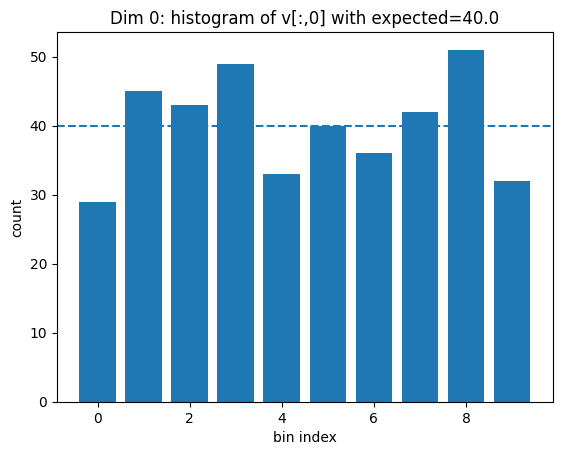

In [ ]:

j = 0
B = 10
counts, edges = np.histogram(v_samp[:, j], bins=B, range=(0,1))
expected = len(v_samp)/B

plt.figure()
plt.bar(range(B), counts)
plt.axhline(expected, linestyle="--")
plt.xlabel("bin index")
plt.ylabel("count")
plt.title(f"Dim {j}: histogram of v[:,{j}] with expected={expected:.1f}")
plt.show()


In [ ]:

# z_0 = np.array([0.0, 0.0])  # baseline configuration
# params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters

# tau = 1 # safety upper threshold for trajectory
# time_window = (6, 10) # inspection window
# T = 10; dt = 0.01 # t \in [0,T] with step dt = 0.01
# seed = 1 # random seed

mean_test = np.array([0,0]); cov_test = np.diag([1.5, 1.5]) # parameters of the X distribution
X_test = sample_x(n_samples = 100, dist_type="gaussian", params={"mean": mean_test, "cov": cov_test}, seed=seed)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T array), position (n * T array), velocity (n * T array)
traj_test = simulate_spring(params, t_final=T, dt=dt, X=X_test, forcing_type='sin', config=z_0)

s_test = traj_test["s"]  # numpy array
assert X.shape[0] == s.shape[0]

# downsample the trajectory to reduce length (optional but recommended)
stride = 5                  # dt=0.01 => stride=10 gives effective dt=0.1
s_ds_test = s_test[:, ::stride]        # (N, T_ds)
T_ds_test = s_ds_test.shape[1]

# build (o_hist, o_next) pairs for next-step prediction
# o_hist: s[0:T-1], o_next: s[1:T]
o_hist = s_ds_test[:, :-1].astype(np.float32)[:, :, None]   # (N, T-1, 1)
o_next = s_ds_test[:,  1:].astype(np.float32)[:, :, None]   # (N, T-1, 1)
x_np_test   = X_test.astype(np.float32)                           # (N, 2)
N_test = x_np_test.shape[0]
test_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
